In [1]:
SEED = 42

In [2]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def header(title, width=80):
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

def subheader(title, width=80):
    print("\n" + "-" * width)
    print(title.center(width))
    print("-" * width)

def kv(key, value, width=30):
    print(f"{key:<{width}} : {value}")

In [4]:
subheader("Загружаем DAIGT")
df = (
    pd.read_csv("../datasets/train_v2_drcat_02.csv", encoding="utf-8").drop_duplicates()[["text", "label"]]
    # .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)
print(f"Загружен датасет 'DAIGT'. {len(df)} записей")


--------------------------------------------------------------------------------
                                Загружаем DAIGT                                 
--------------------------------------------------------------------------------
Загружен датасет 'DAIGT'. 44868 записей


In [5]:
X = df["text"].astype(str)
y = df["label"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

subheader("DATA SPLIT")
kv("Total samples", len(df))
kv("Train", f"{len(X_train)}\t({len(X_train)/len(df):.0%})\t - {sum(y_train)} синтетических")
kv("Test", f"{len(X_test)}\t({len(X_test)/len(df):.0%})\t - {sum(y_test)} синтетических")


--------------------------------------------------------------------------------
                                   DATA SPLIT                                   
--------------------------------------------------------------------------------
Total samples                  : 44868
Train                          : 31407	(70%)	 - 12248 синтетических
Test                           : 13461	(30%)	 - 5249 синтетических


In [6]:
def calculate(X_train, y_train, X_test, y_test):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        ("clf", LogisticRegression(
            random_state=SEED,
            solver="saga",
            max_iter=5000
        )),
    ])
    
    param_grid = {
        "tfidf__max_features": [25000, 35000],
        "clf__C": [1, 10],
        "clf__l1_ratio": [0, 1]  # 0=L2, 1=L1
    }
    
    subheader("HYPERPARAMETER TUNING")
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_macro",
        verbose=0,
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    kv("GridSearch time (s)", f"{elapsed:.2f}")
    kv("Best CV accuracy", f"{grid_search.best_score_:.4f}")
    kv("Best parameters", grid_search.best_params_)
    
    subheader("CROSS-VALIDATION RESULTS (TOP 5)")
    results_df = (
        pd.DataFrame(grid_search.cv_results_)
        .assign(
            max_features=lambda d: d["param_tfidf__max_features"],
            C=lambda d: d["param_clf__C"],
            l1_ratio=lambda d: d["param_clf__l1_ratio"],
            CV_Accuracy=lambda d: d["mean_test_score"]
        )
        .sort_values("CV_Accuracy", ascending=False)
        [["max_features", "C", "l1_ratio", "CV_Accuracy"]]
        .head(5)
    )
    
    print(results_df.to_string(index=False, float_format="%.4f"))
    
    best_model = grid_search.best_estimator_
    
    vectorizer = best_model.named_steps['tfidf']
    clf = best_model.named_steps['clf']
    
    feature_names = vectorizer.get_feature_names_out()
    coef = clf.coef_[0]
    
    top_words = feature_names[np.argsort(coef)[-25:]]
    print("\nТоп слов для СГЕНЕРИРОВАННЫХ текстов:")
    print(*top_words)
    
    bottom_words = feature_names[np.argsort(coef)[:25]]
    print("\nТоп слов для ЖИВЫХ текстов:")
    print(*bottom_words)
    
    train_acc = best_model.score(X_train, y_train)
    test_acc = best_model.score(X_test, y_test)
    
    subheader("ЛУЧШАЯ МОДЕЛЬ")
    kv("Train accuracy", f"{train_acc:.4f}")
    kv("Test accuracy", f"{test_acc:.4f}")

    y_test_proba = best_model.predict_proba(X_test)[:, 1]  # вероятность класса 1

    auprc = average_precision_score(y_test, y_test_proba)
    auroc = roc_auc_score(y_test, y_test_proba)

    kv("AUPRC (Test)", f"{auprc:.4f}")
    kv("AUROC (Test)", f"{auroc:.4f}")
    
    subheader("ИТОГО (TEST)")
    y_test_pred = best_model.predict(X_test)
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=["Human Text", "Generated Text"]
    ))
    
    subheader("CONFUSION MATRIX (TEST)")
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Human", "Generated"],
        yticklabels=["Human", "Generated"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix")
    plt.show()

    return best_model


--------------------------------------------------------------------------------
                             HYPERPARAMETER TUNING                              
--------------------------------------------------------------------------------
GridSearch time (s)            : 582.16
Best CV accuracy               : 0.9937
Best parameters                : {'clf__C': 10, 'clf__l1_ratio': 0, 'tfidf__max_features': 35000}

--------------------------------------------------------------------------------
                        CROSS-VALIDATION RESULTS (TOP 5)                        
--------------------------------------------------------------------------------
 max_features  C  l1_ratio  CV_Accuracy
        35000 10         0       0.9937
        25000 10         0       0.9936
        35000 10         1       0.9899
        25000 10         1       0.9899
        25000  1         0       0.9891

Топ слов для СГЕНЕРИРОВАННЫХ текстов:
cool impact gonna academic consider climate ensures red

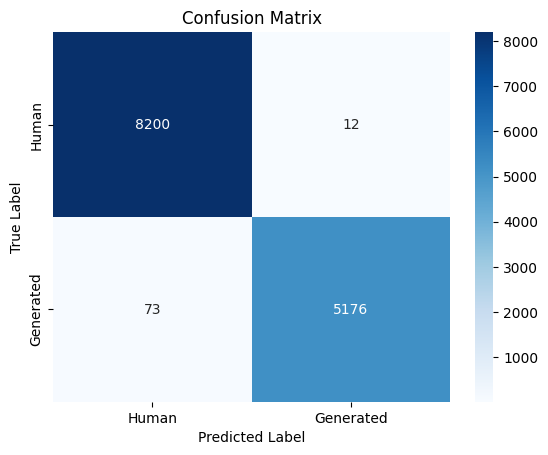

In [7]:
best_model = calculate(X_train, y_train, X_test, y_test)

## Shuffled labels

Перемешаем метки для train, чтобы убедиться в отсутствии утечек. Метрики должны упасть до случайных (~0.50)


--------------------------------------------------------------------------------
                             HYPERPARAMETER TUNING                              
--------------------------------------------------------------------------------


/opt/anaconda3/envs/m2gpu/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearch time (s)            : 5226.06
Best CV accuracy               : 0.4945
Best parameters                : {'clf__C': 10, 'clf__l1_ratio': 1, 'tfidf__max_features': 25000}

--------------------------------------------------------------------------------
                        CROSS-VALIDATION RESULTS (TOP 5)                        
--------------------------------------------------------------------------------
 max_features  C  l1_ratio  CV_Accuracy
        25000 10         1       0.4945
        35000 10         1       0.4943
        25000 10         0       0.4919
        35000 10         0       0.4894
        25000  1         0       0.4334

Топ слов для СГЕНЕРИРОВАННЫХ текстов:
student autonomy like believe projects let based evidence make computer process ensures affect future especially school communicate teachers germany car statement success related activities principle believe encourage candidates day kids limit students states conclusion bad weather require electro

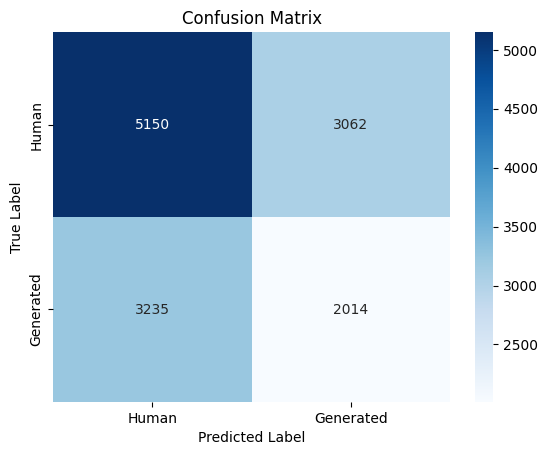

In [8]:
y_train_shuffled = np.random.permutation(y_train)
_ = calculate(X_train, y_train_shuffled, X_test, y_test)

## Примеры текстов

In [9]:
def explain_prediction(text, model):
    vectorizer = model.named_steps['tfidf']
    clf = model.named_steps['clf']

    X_vec = vectorizer.transform([text])

    coef = clf.coef_[0]

    contribution = X_vec.toarray()[0] * coef
    feature_names = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        'word': feature_names,
        'tfidf': X_vec.toarray()[0],
        'coef': coef,
        'contribution': contribution
    })

    df = df[df.tfidf > 0].sort_values('contribution', ascending=False)

    print(f"Предсказанный класс: {model.predict([text])[0]}")
    print("\nСлова, показывающие, что текст СИНТЕТИЧЕСКИЙ:")
    print(df.head(20)[['word', 'contribution']].to_string(index=False))

    print("\nСлова, показывающие, что текст ЖИВОЙ:")
    print(df.tail(20)[['word', 'contribution']].to_string(index=False))

In [10]:
text = df.loc[df["label"] == 1, "text"].iloc[0]
print(text)

 In recent years, technology has had a profound impact on our daily lives and the world around us. From staying connected with loved ones to ordering food online through an app, technology has made our lives easier and more convenient. However, with great power comes great responsibility, and technology can also have negative consequences if used improperly.

One example of this is the spread of misinformation through the internet. It's easy to find articles and sources that may not be accurate or reliable, which can lead to confusion and even harm. Additionally, technology can also pose a threat to our privacy and security if we are not careful about the websites and apps we use.

Despite these potential drawbacks, I believe that technology can be a powerful tool for achieving great things. For example, technology has revolutionized the way we learn and access information. With the internet, we can easily find resources and information on any topic, making it easier to stay informed a

In [11]:
explain_prediction(text, best_model)

Предсказанный класс: 1

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
         word  contribution
    potential      0.713396
    drawbacks      0.453772
 additionally      0.346500
        lives      0.241723
      privacy      0.238801
   conclusion      0.224435
         tool      0.199834
     benefits      0.194376
  furthermore      0.193553
        risks      0.189788
       impact      0.177099
     informed      0.171102
    achieving      0.167683
opportunities      0.163801
         apps      0.162164
   convenient      0.159884
      believe      0.159876
       access      0.159371
    resources      0.153538
         lead      0.151220

Слова, показывающие, что текст ЖИВОЙ:
       word  contribution
   continue     -0.062940
     spread     -0.065089
        way     -0.069266
innovations     -0.069448
     threat     -0.082324
     future     -0.085064
        new     -0.088349
        far     -0.091903
       play     -0.100766
        use     -0.102579
      topic     -

In [12]:
text = df.loc[df["label"] == 0, "text"].iloc[0]
print(text)

Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and forward and just have group Chats on social media. They even do it while driving. They are some really bad consequences when stuff happens when it comes to a phone. Some certain areas in the United States ban phones from class rooms just because of it.

When people have phones, they know about certain apps that they have .Apps like Facebook Twitter Instagram and Snapchat. So like if a friend moves away and you want to be in contact you can still be in contact by posting videos or text messages. People always have different ways how to communicate with a phone. Phones have changed due to our generation.

Driving is one of the way how to get around. People always be on their phones while doing it. Which can cause serious Problems. That's why there's a thing that's called no texting while driving. That's a really important thing to remember. S

In [13]:
explain_prediction(text, best_model)

Предсказанный класс: 0

Слова, показывающие, что текст СИНТЕТИЧЕСКИЙ:
            word  contribution
            apps      0.323591
            like      0.316828
       important      0.250139
           stuff      0.144667
     communicate      0.140552
    social media      0.139243
     like friend      0.132026
        remember      0.127488
really important      0.118531
    consequences      0.113085
    people think      0.106029
         involve      0.101404
           group      0.097695
          number      0.089511
           areas      0.087328
        involves      0.085622
           media      0.085205
         forward      0.077380
        way stay      0.069067
      way people      0.054742

Слова, показывающие, что текст ЖИВОЙ:
           word  contribution
        texting     -0.125310
           stop     -0.125614
          doing     -0.128134
       accident     -0.134670
          class     -0.139344
          cause     -0.156468
            did     -0.159516
